# Pipeline Proyecto Mapper - Análisis Topológico

Esta libreta construye un pipeline limpio para: cargar los datos, convertir SMILES a grafos, calcular una medida de similitud WL, generar la matriz de similitud y derivar la matriz de distancias.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from collections import Counter
from rdkit import Chem
from rdkit.Chem import rdchem
import umap.umap_ as umap

## 1. Cargar datos

Se carga el archivo `NPASSv2.0_structureInfo.txt`, se eliminan valores faltantes y se muestrea un subconjunto para que el cálculo de la matriz sea manejable.

In [7]:
DATA_PATH = "folders/laboratorios/laboratorio_2/NPASSv2.0_structureInfo.txt"
npass = pd.read_csv(DATA_PATH, sep='	', na_values='n.a.')
npass = npass.dropna(subset=['SMILES']).reset_index(drop=True)

subset = npass.sample(1000, random_state=52).reset_index(drop=True)
print('Total registros cargados:', len(npass))
print('Registros usados en el subconjunto:', len(subset))

Total registros cargados: 96235
Registros usados en el subconjunto: 1000


## 2. Convertir SMILES a grafos y calcular etiquetas WL

Se define un pipeline sencillo que convierte cada SMILES en un grafo de RDKit y luego calcula las etiquetas de Weisfeiler-Lehman usando los tipos de enlace.

In [8]:
BOND_MAP = {
    'SINGLE': 1, 'DOUBLE': 2, 'TRIPLE': 3, 'AROMATIC': 12,
    'QUADRUPLE': 4, 'QUINTUPLE': 5, 'HEXTUPLE': 6,
    'ONEANDAHALF': 7, 'TWOANDAHALF': 8, 'THREEANDAHALF': 9,
    'FOURANDAHALF': 10, 'FIVEANDAHALF': 11, 'IONIC': 13,
    'HYDROGEN': 14, 'THREECENTER': 15, 'DATIVEONE': 16,
    'DATIVE': 17, 'DATIVEL': 18, 'DATIVER': 19, 'OTHER': 20,
    'UNSPECIFIED': 0, 'ZERO': 21
}

def smiles_to_graph(smile):
    mol = Chem.MolFromSmiles(smile)
    if mol is None:
        return None
    G = nx.Graph()
    for atom in mol.GetAtoms():
        G.add_node(atom.GetIdx(), atomic_num=atom.GetAtomicNum(), is_aromatic=atom.GetIsAromatic(), atom_symbol=atom.GetSymbol())
    for bond in mol.GetBonds():
        G.add_edge(bond.GetBeginAtomIdx(), bond.GetEndAtomIdx(), bond_type=bond.GetBondType())
    return G

def initial_node_label(G, v):
    a = G.nodes[v]
    return f"{a['atomic_num']}{'A' if a.get('is_aromatic') else ''}"

def bond_label(edge_data):
    bt = edge_data.get('bond_type')
    name = getattr(bt, 'name', str(bt))
    return BOND_MAP.get(name, BOND_MAP['OTHER'])

def wl_con_edges(G, labels):
    new_labels = {}
    for v in G.nodes():
        neigh_sig = []
        for u in G.neighbors(v):
            edge_code = bond_label(G[v][u])
            neigh_sig.append((edge_code, labels[u]))
        neigh_sig.sort()
        new_labels[v] = (labels[v], tuple(neigh_sig))
    return new_labels

def wl_labels(G, h=2):
    labels = {v: initial_node_label(G, v) for v in G.nodes()}
    all_levels = [list(labels.values())]
    for _ in range(h):
        labels = wl_con_edges(G, labels)
        all_levels.append(list(labels.values()))
    return all_levels

def wl_vector(G, h=2):
    labels_by_level = wl_labels(G, h=h)
    fp = Counter()
    for level in labels_by_level:
        fp.update(level)
    return fp

def tanimoto_count(fp1, fp2):
    if not fp1 and not fp2:
        return 1.0
    keys = set(fp1) | set(fp2)
    dot = sum(fp1.get(k, 0) * fp2.get(k, 0) for k in keys)
    norm1 = sum(v*v for v in fp1.values())
    norm2 = sum(v*v for v in fp2.values())
    denom = norm1 + norm2 - dot
    return 0.0 if denom == 0 else float(dot / denom)

def wl_tanimoto(G1, G2, h=2):
    fp1 = wl_vector(G1, h=h)
    fp2 = wl_vector(G2, h=h)
    return tanimoto_count(fp1, fp2)

In [9]:
subset['Graph'] = subset['SMILES'].apply(smiles_to_graph)
subset = subset.dropna(subset=['Graph']).reset_index(drop=True)
print('Grafos válidos en el subconjunto:', len(subset))

[20:03:14] Explicit valence for atom # 1 N, 5, is greater than permitted


Grafos válidos en el subconjunto: 999


## 3. Generar la matriz de similitud y la matriz de distancias

Se calcula la matriz de similitud WL y luego se transforma en una matriz de distancia como `1 - similitud`.

In [10]:
n = len(subset)
similarity_matrix = np.zeros((n, n), dtype=float)
for i in range(n):
    g1 = subset.loc[i, 'Graph']
    for j in range(i, n):
        g2 = subset.loc[j, 'Graph']
        similarity = wl_tanimoto(g1, g2, h=2)
        similarity_matrix[i, j] = similarity
        similarity_matrix[j, i] = similarity

print('Matriz de similitud generada con forma:', similarity_matrix.shape)
distance_matrix = 1.0 - similarity_matrix
print('Matriz de distancias generada con forma:', distance_matrix.shape)

Matriz de similitud generada con forma: (999, 999)
Matriz de distancias generada con forma: (999, 999)


In [11]:
pd.DataFrame(similarity_matrix).to_csv('matriz_similitud_wl.csv', index=False)
pd.DataFrame(distance_matrix).to_csv('matriz_distancias_wl.csv', index=False)
print('Archivos guardados: matriz_similitud_wl.csv, matriz_distancias_wl.csv')

Archivos guardados: matriz_similitud_wl.csv, matriz_distancias_wl.csv


## 4. Aplicacion de filtro de distancia

Se aplica un filtro para eliminar pares de moléculas que estén demasiado cerca (distancia < 0.5) o demasiado lejos (distancia > 0.9) según la matriz de distancias calculada.

## 4. Visualización UMAP

Se usa la matriz de distancia precomputada para proyectar los compuestos en 2D.

c:\Users\narro\AppData\Local\Programs\Python\Python313\Lib\site-packages\umap\umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
c:\Users\narro\AppData\Local\Programs\Python\Python313\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


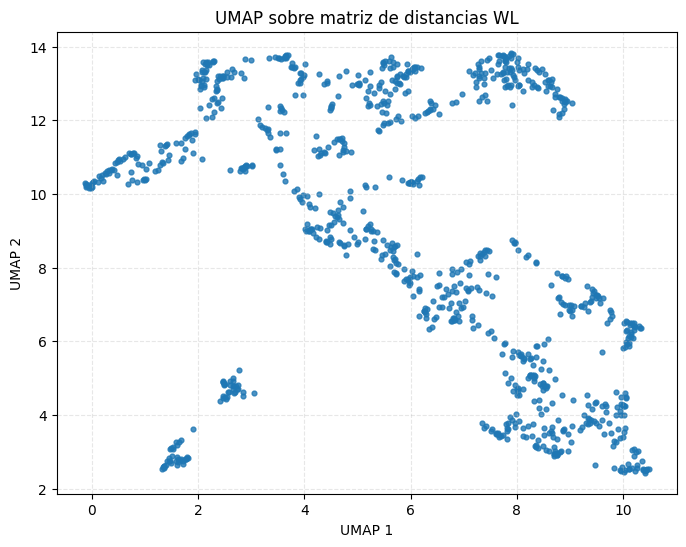

In [12]:
embedding = umap.UMAP(n_components=2, metric='precomputed', random_state=42).fit_transform(distance_matrix)
plt.figure(figsize=(8, 6))
plt.scatter(embedding[:, 0], embedding[:, 1], s=12, alpha=0.8)
plt.title('UMAP sobre matriz de distancias WL')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()